Material de estudo e consulta. Por Yuji Miranda Kunitake

In [23]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Análise de dados multivariados: gráficos, grids e códigos visuais
Este notebook mostra exemplos de visualização de **dados multivariados** usando o conjunto `titanic` do **Seaborn**.

A análise inclui:
- gráficos de barras simples, agrupadas e empilhadas;
- gráficos de densidade para variáveis contínuas;
- códigos visuais (cor, forma e tamanho);
- uso de **Facet Grid** e **Pair Grid** para análise multivariada.

Este material funciona como referência para análise exploratória de dados e interpretação de visualizações categóricas e numéricas.

## Bibliotecas utilizadas
- `seaborn`: criação de gráficos estatísticos avançados.
- `pandas`: manipulação de dados em tabelas.
- `matplotlib.pyplot`: controle de figuras e exibição de gráficos.

In [10]:
titanic = sns.load_dataset('titanic')

## Conjunto de dados
O dataset `titanic` contém informações sobre passageiros do **Titanic**, incluindo variáveis como **classe**, **sexo**, **idade** e **tarifa**.

Esta base é útil para praticar visualizações de dados categóricos e numéricos.

## Gráfico de Barras Simples
O gráfico de barras simples é ideal para comparar valores ou contagens de uma única **variável categórica**.

Use este gráfico para responder perguntas como: qual classe de cabine tem mais passageiros?

- Mostra a **frequência** das categorias;
- É fácil de interpretar;
- Indicado para comparações diretas entre grupos.

### Observações
O `sns.countplot()` é a função ideal para este tipo de visualização, contando automaticamente as ocorrências de cada categoria.

<Axes: xlabel='class', ylabel='count'>

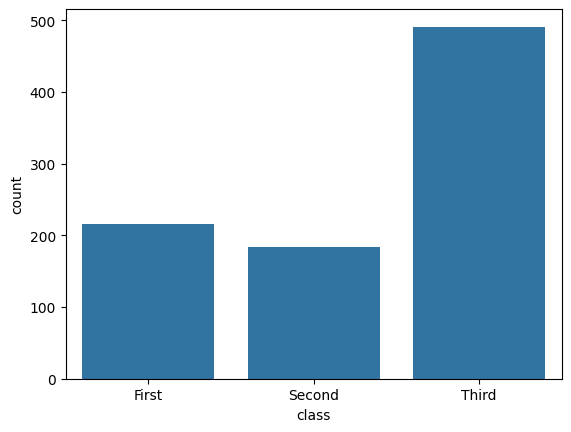

In [11]:
sns.countplot(data=titanic, x='class')

## Gráfico de Barras Agrupadas
Este gráfico mostra a comparação entre **categorias principais** e **subgrupos** associados.

Use-o quando quiser comparar dois atributos categóricos ao mesmo tempo.

- Cada categoria principal tem barras **lado a lado**;
- Permite comparar a mesma subcategoria em diferentes grupos;
- Ajuda a entender a distribuição entre classes e sexos.

### Interpretação
O parâmetro `hue` do `sns.countplot()` define qual variável será usada para separar os subgrupos dentro de cada categoria.

<Axes: xlabel='class', ylabel='count'>

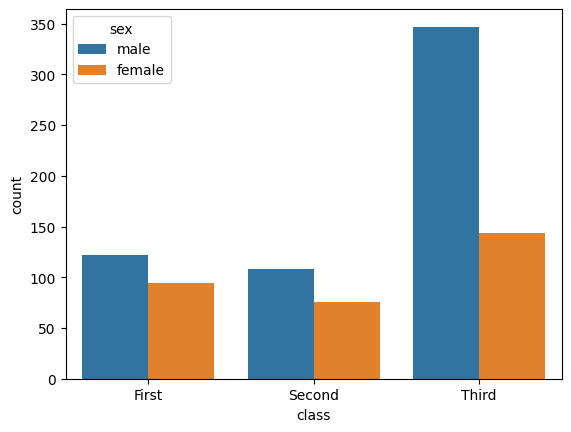

In [12]:
sns.countplot(data=titanic, x='class', hue='sex')

## Gráfico de Barras Empilhadas
O gráfico de barras empilhadas mostra como cada categoria principal é composta por **subcategorias**.

Aqui, ele ilustra a distribuição de passageiros por **classe** e **sexo**.

- A **altura total** indica o valor agregado da categoria principal;
- As **camadas** mostram a proporção de cada subgrupo;
- Útil para comparar composição e volume ao mesmo tempo.

### Observações
A função `pd.crosstab()` combinada com `.plot(kind="bar", stacked=True)` permite construir este tipo de visualização de forma simples.

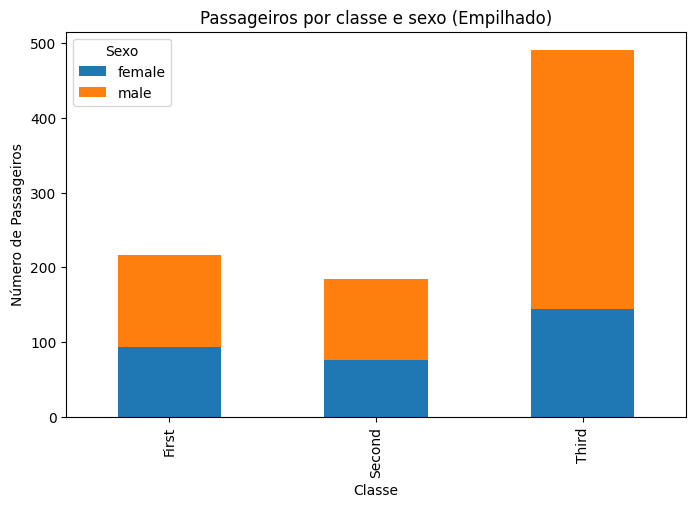

In [14]:
df_empilhado = titanic.groupby(['class', 'sex']).size().unstack()
df_empilhado.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title('Passageiros por classe e sexo (Empilhado)')
plt.xlabel('Classe')
plt.ylabel('Número de Passageiros')
plt.legend(title='Sexo')
plt.show()

## Gráficos de Densidade
Os gráficos de densidade representam a distribuição de uma **variável contínua** de forma suave.

Aqui, temos a distribuição de **idade** geral e por classe de cabine.

- Mostram a forma da distribuição (**picos**, **assimetria**, **dispersão**);
- São úteis para comparar grupos sem usar histogramas;
- A sobreposição de curvas facilita a comparação entre categorias.

### Interpretação
A função `sns.kdeplot()` cria as curvas de densidade. O parâmetro `hue` permite separar as distribuições por categoria, facilitando a comparação visual.

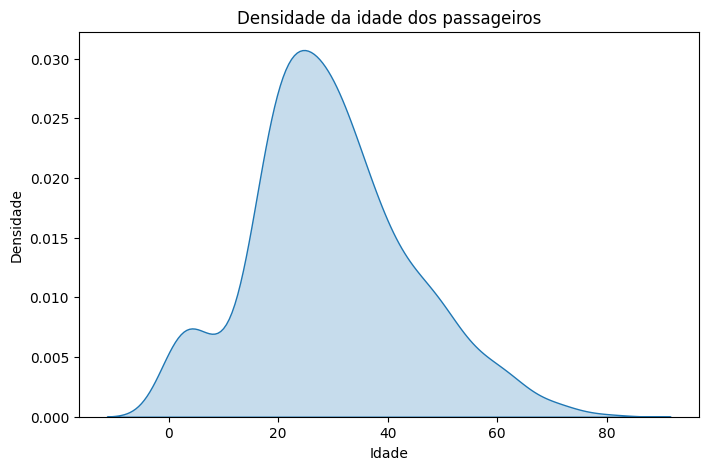

In [15]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=titanic, x='age', fill=True)
plt.title('Densidade da idade dos passageiros')
plt.xlabel('Idade')
plt.ylabel('Densidade')
plt.show()

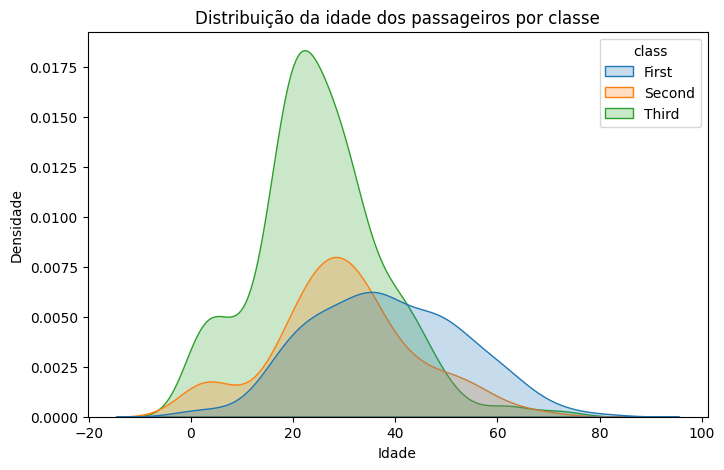

In [16]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=titanic, x='age', hue='class', fill=True)
plt.title('Distribuição da idade dos passageiros por classe')
plt.xlabel('Idade')
plt.ylabel('Densidade')
plt.show()

## Códigos Visuais
Em visualizações multivariadas, **códigos visuais** como cor, forma e tamanho representam variáveis adicionais em um único gráfico.

- A **cor** pode indicar uma categoria;
- A **forma** pode separar subgrupos;
- O **tamanho** pode representar uma medida numérica extra.

### Observações
A função `sns.scatterplot()` aceita os parâmetros `hue`, `style` e `size` para codificar até três variáveis extras em um único gráfico de dispersão.

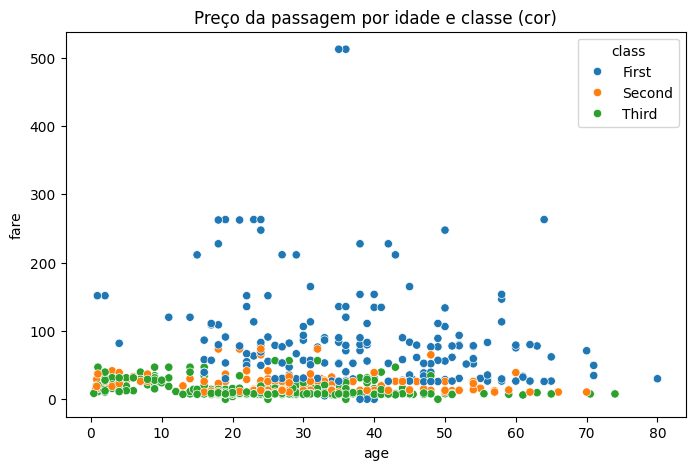

In [18]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=titanic, x='age', y='fare', hue='class')
plt.title('Preço da passagem por idade e classe (cor)')
plt.show()

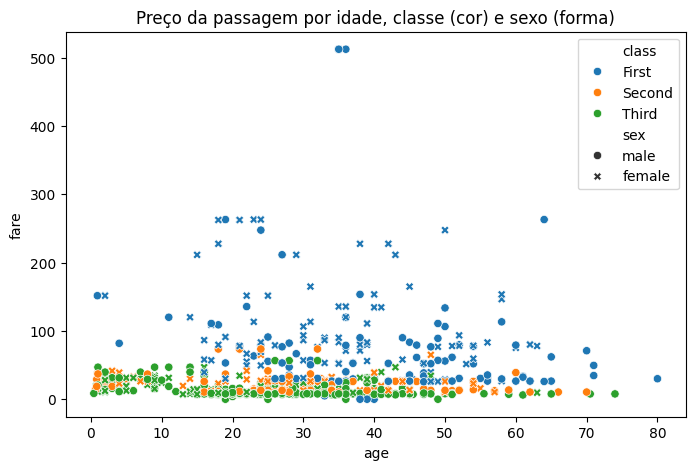

In [19]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=titanic, x='age', y='fare', hue='class', style='sex')
plt.title('Preço da passagem por idade, classe (cor) e sexo (forma)')
plt.show()

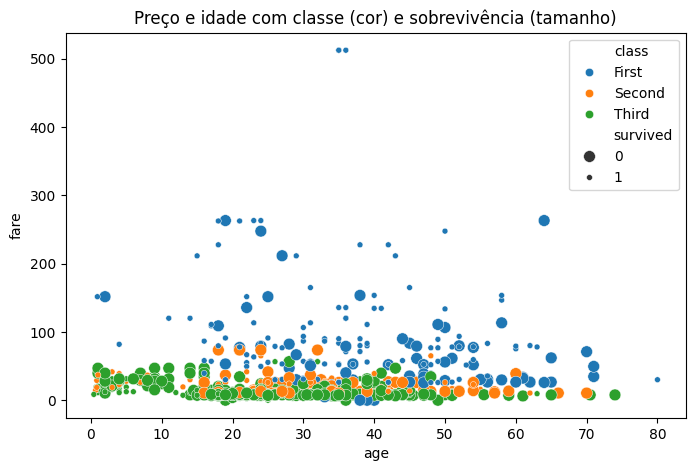

In [20]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=titanic, x='age', y='fare', hue='class', size='survived')
plt.title('Preço e idade com classe (cor) e sobrevivência (tamanho)')
plt.show()

## Facet Grid
O **Facet Grid** organiza gráficos em uma **grade** onde cada célula representa um subconjunto dos dados.

- Facilita a comparação de padrões entre grupos;
- Mantém o **mesmo tipo de gráfico** em cada faceta;
- É útil para analisar como uma variável se comporta em diferentes categorias.

### Interpretação
A classe `sns.FacetGrid()` define a grade e o método `.map()` aplica o gráfico desejado a cada subconjunto dos dados.

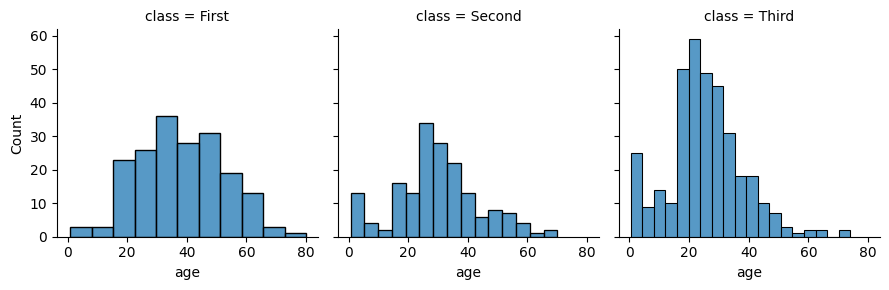

In [21]:
g = sns.FacetGrid(titanic, col='class')
g.map(sns.histplot, 'age')
plt.show()

## Pair Grid
O **Pair Grid** cria uma **matriz de gráficos** para todas as combinações entre variáveis numéricas.

- A **diagonal** mostra a distribuição de cada variável;
- As células **fora da diagonal** mostram a relação entre pares de variáveis;
- Permite identificar **correlações** e padrões bivariados.

### Interpretação
A classe `sns.PairGrid()` permite personalizar cada região da matriz: use `.map_diag()` para a diagonal, `.map_upper()` para o triângulo superior e `.map_lower()` para o inferior.

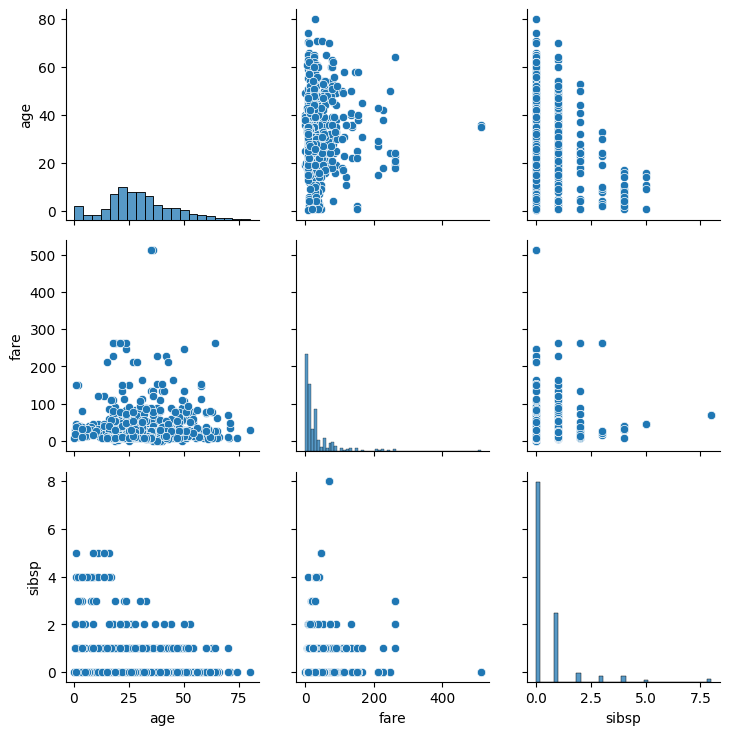

In [22]:
g = sns.PairGrid(titanic, vars=['age', 'fare', 'sibsp'])
g.map_diag(sns.histplot)
g.map_offdiag(sns.scatterplot)
plt.show()

## Conclusões
- O **mapa de barras** (simples, agrupadas e empilhadas) facilita a comparação de contagens e proporções entre categorias.
- A **densidade** ilustra a distribuição contínua de forma suave e comparável.
- Os **códigos visuais** combinam informações usando cor, forma e tamanho em um único gráfico.
- O **Facet Grid** e o **Pair Grid** organizam múltiplas visualizações para análise comparativa.

Este notebook é um material de consulta útil para análise exploratória de dados e interpretação de visualizações multivariadas.